In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Câu 1

### Đọc dữ liệu

In [3]:
df = pd.read_csv(r"employee_sample_data.csv", encoding='latin-1')

#### a. Các cột và các kiểu dữ liệu tương ứng của mỗi cột

In [4]:
print(df.dtypes)

Employee ID       object
Full Name         object
Job Title         object
Department        object
Business Unit     object
Gender            object
Ethnicity         object
Age              float64
Hire Date         object
Annual Salary     object
Bonus %           object
Country           object
City              object
Exit Date         object
dtype: object


#### b. 10 dòng dữ liệu số đầu tiên 

In [5]:
df.head(10).select_dtypes(include="number")

,Age
0,47.0
1,58.0
2,34.0
3,39.0
4,42.0
5,62.0
6,58.0
7,62.0
8,38.0
9,52.0


#### c. Kiểm tra dữ liệu thiếu và in ra số lượng thiếu nếu có

In [6]:
print(df.isna().values.any())

True


In [7]:
print(df.isna().sum())

Employee ID        19
Full Name          40
Job Title          58
Department         47
Business Unit      82
Gender             49
Ethnicity          42
Age                 6
Hire Date          35
Annual Salary      73
Bonus %            48
Country           106
City               55
Exit Date        1137
dtype: int64


# Câu 2

In [8]:
def find_employee(df, MSSV):
    try:
        last_4_digits= int(MSSV[-4:]) # chuyển về số nguyên
    except:
        raise ValueError("Invalid Student ID")
    
    N = len(df) # đếm tổng số dòng
    index = last_4_digits % N # tính index

    if index % 2 == 0:
        idx = index
    elif index % 2 != 0:
        idx = index - 1
    elif index == 0:
        idx = -1
    
    df_idx = df.iloc[idx] # Lấy nhân viên X
    employee_id = df_idx['Employee ID']
    full_name = df_idx['Full Name']
    department = df_idx['Department']
    annual_salary = df_idx['Annual Salary']

    # In ra các thông tin của nhân viên X
    print(f"Employee ID: {employee_id},",
          f"Full Name: {full_name},",
          f"Department: {department},",
          f"Annual Salary: {annual_salary}")
    
    return df_idx

In [9]:
x = '030140240029'
X_employee = find_employee(df, x)

Employee ID: E02030, Full Name: Peyton Wright, Department: Marketing, Annual Salary: $153,370 


# Câu 3

#### Hiển thị thông tin của nhân viên X ở câu 2

In [10]:
X_employee.drop(['Business Unit', 'Ethnicity', 'Hire Date', 'Exit Date']).to_frame()

,28
Employee ID,E02030
Full Name,Peyton Wright
Job Title,Sr. Manager
Department,Marketing
Gender,Female
Age,41.0
Annual Salary,"$153,370"
Bonus %,10%
Country,United States
City,Chicago


#### Xử lí dữ liệu lương

In [11]:
df['Annual Salary'] = df['Annual Salary'].dropna().apply(
    lambda x: str(x).replace('$', '').replace(',', '')
    ).astype(int)

#### Mức lương trung bình của toàn bộ công ty

In [12]:
avg_salary = df['Annual Salary'].mean() #
print(f"Average salary: ${int(avg_salary)}")

Average salary: $110005


#### So sánh Lương của nhân viên X so với mức lương trung bình của công ty

In [13]:
X_salary = int(X_employee['Annual Salary'][1:4] + X_employee['Annual Salary'][5:-1])

if X_salary > avg_salary:
    print(f"X employee salary ${X_salary} is higher than the average salary of the company ${int(avg_salary)}")
elif X_salary < avg_salary:
    print(f"X employee salary ${X_salary} is lower than the average salary of the company ${int(avg_salary)}")
else:
    print(f"X employee salary ${X_salary} is equal to the average salary of the company ${int(avg_salary)}")

X employee salary $153370 is higher than the average salary of the company $110005


# Câu 4

#### Thống kê trên phòng ban mà nhân viên X đang làm

In [14]:
X_department = df[df['Department'] == X_employee['Department']]

print(f"Total employees of the department: {len(X_department)}")
print('-'*50)

print(f"Average salary of the department: ${int(X_department['Annual Salary'].mean())}")
print('-'*50)

print(f"Highest salary of the department: ${int(X_department['Annual Salary'].max())}")
print('-'*50)

print(f"Lowest salary of the department: ${int(X_department['Annual Salary'].min())}")
print('-'*50)

print(f"Average age of the employees of the department: {int(X_department['Age'].mean())}")

Total employees of the department: 136
--------------------------------------------------
Average salary of the department: $126982
--------------------------------------------------
Highest salary of the department: $257296
--------------------------------------------------
Lowest salary of the department: $40778
--------------------------------------------------
Average age of the employees of the department: 42


#### So sánh lương của nhân viên X và lương trung bình của phòng ban

In [15]:
if X_salary > avg_salary:
    print(f"X employee salary ${X_salary} is higher than the average salary of the department")
elif X_salary < avg_salary:
    print(f"X employee salary ${X_salary} is lower than the average salary of the department")
else:
    print(f"X employee salary ${X_salary} is approximately equal to the average salary of the department")

X employee salary $153370 is higher than the average salary of the department


#### Chênh lệch tuyệt đối giữa lương của nhân viên X và lương trung bình của phòng ban

In [16]:
abs_diff = abs(X_salary -X_department['Annual Salary'].mean())
print(f"Absolute difference between X salary and average of the department: ${abs_diff}")

Absolute difference between X salary and average of the department: $26387.39230769231


# Câu 5

#### Tạo cột Salary_Level

In [17]:
q25 = df['Annual Salary'].quantile(0.25) # Tính phân vị 75%
q75 = df['Annual Salary'].quantile(0.75) # Tính phân vị 25%

df['Salary_Level'] = pd.cut(
    df['Annual Salary'],
    bins=[-float('inf'), q25, q75, float('inf')],
    labels=["Low", "Medium", "High"] # Gán các giá trị
)

#### Tạo cột Age_Group

In [18]:
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[-float('inf'), 30, 50, float('inf')],
    labels=["Young", "Middle", "Senior"], # Gán các giá trị
    right=False
)

#### 10 dòng đầu tiên sau khi thêm 2 cột mới

In [19]:
df.head(10)

,Employee ID,Full Name,Job Title,Department,Business Unit,Gender,Ethnicity,Age,Hire Date,Annual Salary,Bonus %,Country,City,Exit Date,Salary_Level,Age_Group
0,E02002,Kai Le,Controls Engineer,Engineering,Manufacturing,Male,Asian,47.0,2/5/2022,92368.0,0%,United States,Columbus,NaN,Medium,Middle
1,E02003,Robert Patel,Analyst,Sales,Corporate,Male,Asian,58.0,10/23/2013,45703.0,0%,United States,Chicago,NaN,Low,Senior
2,E02004,Cameron Lo,Network Administrator,IT,Research & Development,Male,Asian,34.0,3/24/2019,83576.0,0%,China,Shanghai,NaN,Medium,Middle
3,E02005,Harper Castillo,IT Systems Architect,IT,Corporate,Female,Latino,39.0,4/7/2018,98062.0,0%,United States,Seattle,NaN,Medium,Middle
4,E02006,Harper Dominguez,Director,Engineering,Corporate,Female,Latino,42.0,6/18/2005,175391.0,24%,United States,Austin,NaN,High,Middle
5,E02007,Ezra Vu,Network Administrator,IT,Manufacturing,Male,Asian,62.0,4/22/2004,66227.0,0%,United States,Phoenix,2/14/2014,Low,Senior
6,E02008,Jade Hu,Sr. Analyst,Accounting,Specialty Products,Female,Asian,58.0,6/27/2009,89744.0,0%,China,Chongqing,NaN,Medium,Senior
7,E02009,Miles Chang,Analyst II,Finance,Corporate,Male,Asian,62.0,2/19/1999,69674.0,0%,China,Chengdu,NaN,Low,Senior
8,E02010,Gianna Holmes,System Administrator,IT,Manufacturing,Female,Caucasian,38.0,9/9/2011,97630.0,0%,United States,Seattle,NaN,Medium,Middle
9,E02011,Jameson Thomas,Manager,Finance,Specialty Products,Male,Caucasian,52.0,2/5/2015,105879.0,10%,United States,Miami,NaN,Medium,Senior


# Câu 6

#### Tạo cột Salary_Comparison

In [20]:
# Tính lương trung bình theo phòng ban
mean_salary = df.groupby('Department')['Annual Salary'].transform('mean')

df['Salary_Comparison'] = np.where(
    df['Annual Salary'] > mean_salary, 1,
    np.where(df['Annual Salary'] < mean_salary, -1, 0)
)

#### 10 dòng đầu tiên gồm các cột

In [21]:
df[['Full Name', 'Department', 'Annual Salary', 'Salary_Level', 'Age_Group', 'Salary_Comparison']].head(10)

,Full Name,Department,Annual Salary,Salary_Level,Age_Group,Salary_Comparison
0,Kai Le,Engineering,92368.0,Medium,Middle,-1
1,Robert Patel,Sales,45703.0,Low,Senior,-1
2,Cameron Lo,IT,83576.0,Medium,Middle,-1
3,Harper Castillo,IT,98062.0,Medium,Middle,1
4,Harper Dominguez,Engineering,175391.0,High,Middle,1
5,Ezra Vu,IT,66227.0,Low,Senior,-1
6,Jade Hu,Accounting,89744.0,Medium,Senior,-1
7,Miles Chang,Finance,69674.0,Low,Senior,-1
8,Gianna Holmes,IT,97630.0,Medium,Middle,1
9,Jameson Thomas,Finance,105879.0,Medium,Senior,-1


#### Lưu toàn bộ dữ liệu sau khi đã thêm các cột mới

In [22]:
df.to_csv('employee_processed.csv', index=False)

# Câu 7

#### Đọc file dữ liệu mới nhất

In [23]:
df = pd.read_csv('employee_processed.csv')

#### Vẽ biểu đồ cột để so sánh mức lương trung bình của các department

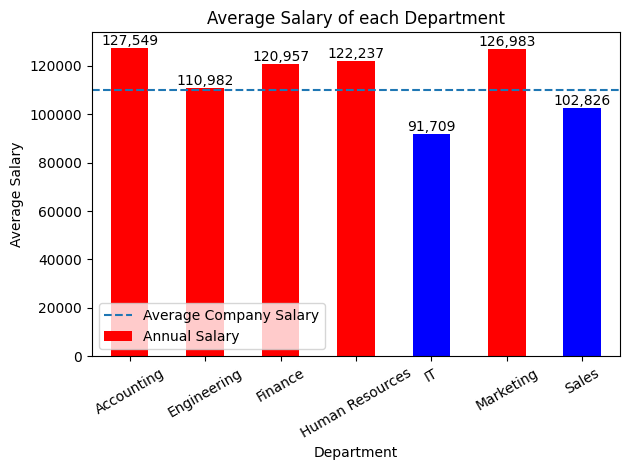

In [24]:
# Tính lương trung bình theo phòng ban
avg_department = df.groupby('Department')['Annual Salary'].mean()

# Gán màu đỏ cho các cột cao hơn lương trung bình và ngược lại với màu xanh
colors = ['red' if dept > avg_salary else 'blue' for dept in avg_department]

# Vẽ biểu đồ cột
ax = avg_department.plot(kind='bar', color=colors)

# Vẽ đường ngang đứt đoạn tượng trưng cho lương trung bình của công ty
plt.axhline(y=avg_salary, linestyle='--', label='Average Company Salary')

# Hiển thị lương trung bình của từng phòng ban theo các cột tương ứng
for i, v in enumerate(avg_department):
    ax.text(i, v, f'{v:,.0f}', ha='center', va='bottom')

plt.xlabel('Department')
plt.ylabel('Average Salary')
plt.title('Average Salary of each Department')
plt.xticks(rotation=30)

plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

In [25]:
# Danh sách các phòng ban có mức lương trung bình cao hơn trung bình của công ty
higher_departments = avg_department[avg_department > avg_salary]

print("Departments with above-average salary:")
higher_departments.to_frame().reset_index()

Departments with above-average salary:


,Department,Annual Salary
0,Accounting,127548.866142
1,Engineering,110982.183007
2,Finance,120956.865079
3,Human Resources,122237.455285
4,Marketing,126982.607692


# Câu 8

#### Thống kê số lượng nhân viên theo giới tính

In [26]:
print(df.groupby('Gender').size())

Gender
Female    632
Male      581
dtype: int64


#### Thống kê số lượng nhân viên theo phòng ban

In [27]:
print(df.groupby('Department').size())

Department
Accounting         132
Engineering        159
Finance            129
Human Resources    124
IT                 347
Marketing          136
Sales              188
dtype: int64


#### Thống kê số lượng nhân viên theo cặp giới tính và phòng ban

In [28]:
print(df.groupby(['Gender', 'Department']).size())

Gender  Department     
Female  Accounting          67
        Engineering         82
        Finance             65
        Human Resources     65
        IT                 164
        Marketing           72
        Sales               96
Male    Accounting          64
        Engineering         73
        Finance             58
        Human Resources     55
        IT                 171
        Marketing           60
        Sales               84
dtype: int64


#### Tính độ tuổi trung bình theo từng phòng ban và xác định phòng ban có tuổi trung bình cao và thấp nhất

In [29]:
avg_age_department = df.groupby('Department')['Age'].mean()

max_department, max_value = avg_age_department.idxmax(), avg_age_department.max()
print("Department have highest average age:")
print(f"{max_department}: {round(max_value)}")

print('-'*50)

min_department, min_value = avg_age_department.idxmin(), avg_age_department.min()
print("Department have lowest average age:")
print(f"{min_department}: {round(min_value)}")

Department have highest average age:
Finance: 47
--------------------------------------------------
Department have lowest average age:
Marketing: 42


#### Biểu đồ mối quan hệ giữa tuổi và lương của các nhân viên

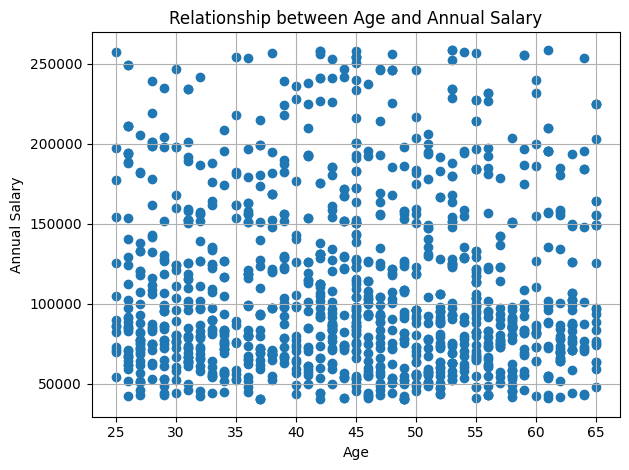

In [30]:
plt.scatter(df['Age'], df['Annual Salary'])
plt.xlabel('Age')
plt.ylabel('Annual Salary')
plt.title('Relationship between Age and Annual Salary')

plt.grid(True)
plt.tight_layout()
plt.show()

#### Tuổi tăng không cho thấy xu hướng lương tăng rõ rệt, mối quan hệ giữa tuổi và lương là yếu hoặc gần như không đáng kể.

# Câu 9

In [31]:
df = df.dropna() # Xóa các hàng thiếu giá trị

#### X bao gồm các biến độc lập, y là biến phụ thuộc

In [32]:
X = df[['Age', 'Gender', 'Department', 'Job Title']]
y = df['Annual Salary']

#### Mã hóa các biến độc lập không phải số về dạng số

In [33]:
X_encoded = pd.get_dummies(X, columns=['Gender', 'Department', 'Job Title'], drop_first=True)

#### Chia ra tập huấn luyện gồm 80% dữ liệu và tập kiểm thử gồm 20% còn lại

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

#### Tạo và huấn luyện mô hình

In [35]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### In ra các hệ số hồi quy tương ứng với từng biến đầu vào

In [36]:
coefficients = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Coefficient': model.coef_
})

print(coefficients)

                                     Feature    Coefficient
0                                        Age     104.989818
1                                Gender_Male     589.205935
2                     Department_Engineering  -12753.767773
3                         Department_Finance   -1296.382594
4                 Department_Human Resources    6320.633127
5                              Department_IT   15662.729658
6                       Department_Marketing  -18301.358868
7                           Department_Sales    5404.878297
8                       Job Title_Analyst II   17993.683484
9              Job Title_Automation Engineer   84086.662084
10                Job Title_Business Partner   -5498.880556
11  Job Title_Cloud Infrastructure Architect   13995.147684
12        Job Title_Computer Systems Manager   23902.981420
13            Job Title_Development Engineer   51758.030928
14                        Job Title_Director  114804.817110
15            Job Title_Enterprise Archi

#### Tính điểm R-squared

In [37]:
r2 = model.score(X_test, y_test)
print("R-squared:", r2)

R-squared: 0.9301099416970099


#### Dự đoán trên tập kiểm tra

In [38]:
y_pred = model.predict(X_test)

#### So sánh 10 giá trị thật và dự đoán

In [39]:
comparison = pd.DataFrame({
    'Actual Salary': y_test.values,
    'Predicted Salary': y_pred
})

print(comparison.head(10))

   Actual Salary  Predicted Salary
0       158403.0     153141.198704
1        93872.0      74298.745454
2        41275.0      43387.327311
3        66660.0      80779.583640
4        78212.0      85425.755636
5        94857.0      90400.205935
6        89379.0      90372.447922
7        79764.0      79414.716004
8        82963.0      72968.547918
9        66227.0      80535.981934


# Câu 10

#### Lọc X gồm 2 biến tuổi và lương

In [40]:
X = df[['Age', 'Annual Salary']]

#### Chuẩn hóa z-score trước khi phân cụm

In [41]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### Tạo và huấn luyện mô hình với 3 cụm và gắn nhãn cho các nhân viên

In [42]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

#### Hiển thị số lượng nhân viên của các cụm

In [43]:
cluster_counts = df['Cluster'].value_counts()
print(cluster_counts)

Cluster
2    47
0    37
1    18
Name: count, dtype: int64


#### Tuổi và lương trung bình của các cụm

In [44]:
cluster_summary = df.groupby('Cluster')[['Age', 'Annual Salary']].mean()
print(cluster_summary)

               Age  Annual Salary
Cluster                          
0        54.702703   86094.918919
1        40.388889  186542.444444
2        36.063830   71739.765957


#### Scatter plot thể hiện phân bố của các cụm

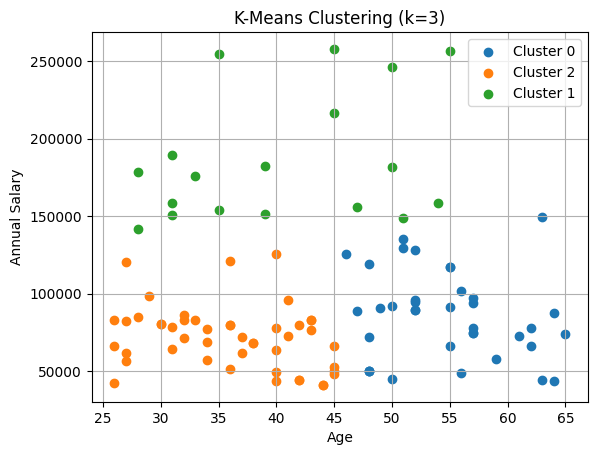

In [45]:
for cluster in df['Cluster'].unique():
    subset = df[df['Cluster'] == cluster]
    plt.scatter(subset['Age'], subset['Annual Salary'], label=f'Cluster {cluster}')

plt.xlabel('Age')
plt.ylabel('Annual Salary')
plt.title('K-Means Clustering (k=3)')
plt.legend()
plt.grid(True)

plt.show()

Cluster 0 (màu xanh dương):
Nhóm tuổi trung bình đến lớn (45–65) với mức lương trung bình (~70k–130k). 

Cluster 1 (màu xanh lá):
Nhóm có mức lương cao nhất (~140k–260k), độ tuổi trải rộng (30–55).

Cluster 2 (màu cam):
Nhóm trẻ tuổi (khoảng 25–40) với mức lương thấp đến trung bình (~40k–90k).